In [13]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.spatial.distance import cosine

random.seed(42)
np.random.seed(42)
print(" Imports  Réussie ")

 Imports  Réussie 


In [12]:
categories = ['Tech', 'Fitness', 'Musique', 'Danse', 'Culture', 'Tourisme']

actions_par_categorie = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia',
                 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle',
                 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste',
                 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance',
                 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art',
                 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage',
                 'reservation_vol', 'achat_guide'],
}

prenoms = ["Alice", "Bob", "Clara", "David", "Emma", "François", "Grace", "Hugo",
           "Inès", "Jules", "Karim", "Laura", "Mohamed", "Nina", "Oscar", "Priya",
           "Quentin", "Rania", "Sébastien", "Tina", "Ugo", "Valeria", "William",
           "Xena", "Yann", "Zoé", "Axel", "Béatrice", "Cédric", "Diane"]

noms_famille = ["Martin", "Bernard", "Dubois", "Thomas", "Petit", "Durand", "Simon",
                "Roux", "Morel", "Girard", "André", "Lefebvre", "Leroy", "Moreau",
                "Perrin", "Laurent", "Blanc", "Gauthier", "Garcia", "Meyer"]

print(" Configuration Réussie")

 Configuration Réussie


In [14]:
# Fonctions de génération sale
def generer_age_sale():
    tirage = random.random()
    if tirage < 0.06:
        return np.nan                              # 6% → NaN
    elif tirage < 0.07:
        return random.choice([-5, -12, -1, -8, -3])  # 1% → négatif
    elif tirage < 0.08:
        return random.choice([150, 200, 312, 999, 180])  # 1% → aberrant
    else:
        return random.randint(15, 65)             # 92% → normal

def generer_interet_sale(interet_reel):
    if random.random() < 0.05:
        return np.nan                              # 5% → NaN
    return interet_reel

def generer_nom_sale(prenom, nom):
    if random.random() < 0.03:
        return ""                                  # 3% → vide
    return f"{prenom} {nom}"

print(" Fonctions définies")

 Fonctions définies


In [ ]:
#Génération du dataset brut
donnees = []
for i in range(600):
    interet_reel = random.choice(categories)
    logs         = random.choices(actions_par_categorie[interet_reel], k=random.randint(2, 5))
    prenom       = random.choice(prenoms)
    nom          = random.choice(noms_famille)
    donnees.append({
        'NOM':            generer_nom_sale(prenom, nom),
        'AGE':            generer_age_sale(),
        'Centre_interet': generer_interet_sale(interet_reel),
        'activity_log':   logs,
    })

df = pd.DataFrame(donnees)

# Doublons : 5 utilisateurs soumettent leur formulaire deux fois
indices_doublon = random.sample(range(len(df)), 5)
doublons        = df.iloc[indices_doublon].copy()
df              = pd.concat([df, doublons], ignore_index=True)
df              = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Lignes totales     : {len(df)}")
print(f"NaN AGE            : {df['AGE'].isna().sum()}")
print(f"NaN Centre_interet : {df['Centre_interet'].isna().sum()}")
print(f"Âges négatifs      : {(df['AGE'] < 0).sum()}")
print(f"Âges > 80          : {(df['AGE'] > 80).sum()}")
print(f"Noms vides         : {(df['NOM'] == '').sum()}")
print(f"Doublons           : {df.duplicated(subset=['NOM','AGE','Centre_interet']).sum()}")
df[['NOM', 'AGE', 'Centre_interet']].head(10)

Lignes totales     : 605
NaN AGE            : 39
NaN Centre_interet : 30
Âges négatifs      : 5
Âges > 80          : 6
Noms vides         : 20
Doublons           : 7


,NOM,AGE,Centre_interet
0,Rania Leroy,33.0,Tourisme
1,Axel Moreau,62.0,Fitness
2,Mohamed Bernard,60.0,Danse
3,Karim Gauthier,41.0,Danse
4,Hugo Roux,35.0,Tourisme
5,Nina Moreau,64.0,Culture
6,Grace Blanc,59.0,Culture
7,Bob André,19.0,Musique
8,William Durand,54.0,Danse
9,David Simon,33.0,Tech


In [ ]:
#Prétraitement

df_clean  = df.copy()
n_initial = len(df_clean)

# PP1 — Suppression doublons
df_clean = df_clean.drop_duplicates(subset=['NOM', 'AGE', 'Centre_interet'])
print(f"[PP1] Doublons supprimés        : {n_initial - len(df_clean)}")

# PP2 — Suppression noms vides
avant    = len(df_clean)
df_clean = df_clean[df_clean['NOM'].str.strip() != ""]
print(f"[PP2] Noms vides supprimés      : {avant - len(df_clean)}")

# PP3 — Correction âges aberrants → médiane
ages_saines = df_clean['AGE'].dropna()
ages_saines = ages_saines[(ages_saines >= 15) & (ages_saines <= 80)]
mediane_age = ages_saines.median()
masque_aber = df_clean['AGE'].notna() & ((df_clean['AGE'] < 15) | (df_clean['AGE'] > 80))
df_clean.loc[masque_aber, 'AGE'] = mediane_age
print(f"[PP3] Âges aberrants corrigés   : {masque_aber.sum()}  → médiane = {mediane_age}")

# PP4 — Imputation NaN AGE → médiane
n_nan_age       = df_clean['AGE'].isna().sum()
df_clean['AGE'] = df_clean['AGE'].fillna(mediane_age)
print(f"[PP4] NaN AGE imputés           : {n_nan_age}")

# PP5 — Imputation NaN Centre_interet → mode
mode_cat                   = df_clean['Centre_interet'].mode()[0]
n_nan_cat                  = df_clean['Centre_interet'].isna().sum()
df_clean['Centre_interet'] = df_clean['Centre_interet'].fillna(mode_cat)
print(f"[PP5] NaN Centre_interet imputés: {n_nan_cat}  → mode = '{mode_cat}'")

# PP6 — Cast AGE en entier
df_clean['AGE'] = df_clean['AGE'].astype(int)

print(f"\nLignes avant : {n_initial}  |  Lignes après : {len(df_clean)}")
df_clean[['NOM', 'AGE', 'Centre_interet']].head(10)

[PP1] Doublons supprimés        : 7
[PP2] Noms vides supprimés      : 20
[PP3] Âges aberrants corrigés   : 11  → médiane = 40.0
[PP4] NaN AGE imputés           : 38
[PP5] NaN Centre_interet imputés: 30  → mode = 'Danse'

Lignes avant : 605  |  Lignes après : 578


,NOM,AGE,Centre_interet
0,Rania Leroy,33,Tourisme
1,Axel Moreau,62,Fitness
2,Mohamed Bernard,60,Danse
3,Karim Gauthier,41,Danse
4,Hugo Roux,35,Tourisme
5,Nina Moreau,64,Culture
6,Grace Blanc,59,Culture
7,Bob André,19,Musique
8,William Durand,54,Danse
9,David Simon,33,Tech


In [ ]:
#Test Chi²

rows_exp = []
for _, row in df_clean.iterrows():
    for action in row['activity_log']:
        rows_exp.append({'Centre_interet': row['Centre_interet'], 'action': action})
df_exp = pd.DataFrame(rows_exp)

contingence = pd.crosstab(df_exp['Centre_interet'], df_exp['action'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingence)

print(f"Chi²     = {chi2_stat:.2f}")
print(f"p-value  = {p_value:.2e}")
print(f"Degrés   = {dof}")
print(f"Résultat : {'Corrélation significative ' if p_value < 0.05 else 'Pas de corrélation ❌'}")
contingence.iloc[:, :5]

Chi²     = 9092.74
p-value  = 0.00e+00
Degrés   = 145
Résultat : Corrélation significative 


action,achat_album,achat_gadget,achat_guide,achat_livre,achat_produit_sport
Centre_interet,,,,,
Culture,0,0,0,65,0
Danse,3,3,5,5,3
Fitness,0,0,0,0,73
Musique,64,0,0,0,0
Tech,0,52,0,0,0
Tourisme,0,0,58,0,0


In [ ]:
#Moteur de recommandation

recommandations = {
    'Tech':     ['Blog IA du Monde', 'Tuto Python avancé', 'Podcast Tech Weekly'],
    'Fitness':  ['Programme HIIT 30j', 'Recettes protéinées', 'App MyFitnessPal'],
    'Musique':  ['Playlist Trending 2024', 'Concert Live VR', 'Mix DJ du mois'],
    'Danse':    ['Chorégraphie TikTok virale', 'Cours salsa en ligne', 'Battle danse Paris'],
    'Culture':  ['Expo Louvre virtuelle', 'Podcast Historia', 'Livre Prix Goncourt'],
    'Tourisme': ['Top 10 destinations 2024', 'Guide Barcelone', 'Road trip USA'],
}

all_actions = sorted({a for acts in actions_par_categorie.values() for a in acts})

def encode_user(activity_log):
    vec = np.zeros(len(all_actions))
    for a in activity_log:
        if a in all_actions:
            vec[all_actions.index(a)] += 1
    return vec

class RecommendationEngine:
    def __init__(self, df):
        self.df      = df.reset_index(drop=True)
        self.vectors = np.array([encode_user(r['activity_log']) for _, r in df.iterrows()])

    def get_similar_users(self, user_idx, n=3):
        u_vec  = self.vectors[user_idx]
        scores = []
        for i, v in enumerate(self.vectors):
            if i == user_idx: continue
            if np.linalg.norm(u_vec) == 0 or np.linalg.norm(v) == 0: continue
            scores.append((i, 1 - cosine(u_vec, v)))
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def recommend(self, user_idx):
        user = self.df.iloc[user_idx]
        cat  = user['Centre_interet']
        return {
            'utilisateur':     user['NOM'],
            'age':             user['AGE'],
            'interet':         cat,
            'recommandations': recommandations.get(cat, []),
            'similaires':      [self.df.iloc[i]['NOM'] for i, _ in self.get_similar_users(user_idx)],
        }

engine = RecommendationEngine(df_clean)

for idx in [0, 15, 42]:
    r = engine.recommend(idx)
    print(f"\n→ {r['utilisateur']} | {r['age']} ans | {r['interet']}")
    print(f"  Reco       : {', '.join(r['recommandations'])}")
    print(f"  Similaires : {', '.join(r['similaires'])}")


→ Rania Leroy | 33 ans | Tourisme
  Reco       : Top 10 destinations 2024, Guide Barcelone, Road trip USA
  Similaires : Ugo Laurent, Ugo Leroy, Tina Laurent

→ Emma Moreau | 22 ans | Danse
  Reco       : Chorégraphie TikTok virale, Cours salsa en ligne, Battle danse Paris
  Similaires : Sébastien Roux, Cédric Thomas, Xena Gauthier

→ Xena Blanc | 37 ans | Danse
  Reco       : Chorégraphie TikTok virale, Cours salsa en ligne, Battle danse Paris
  Similaires : William Durand, Béatrice Girard, Karim Gauthier


/tmp/ipykernel_475/2394085951.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cat_counts.index, rotation=30, ha='right', fontfamily='monospace')
/tmp/ipykernel_475/2394085951.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7.set_xticklabels(avg_actions.index, rotation=30, ha='right', fontfamily='monospace')
/tmp/ipykernel_475/2394085951.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


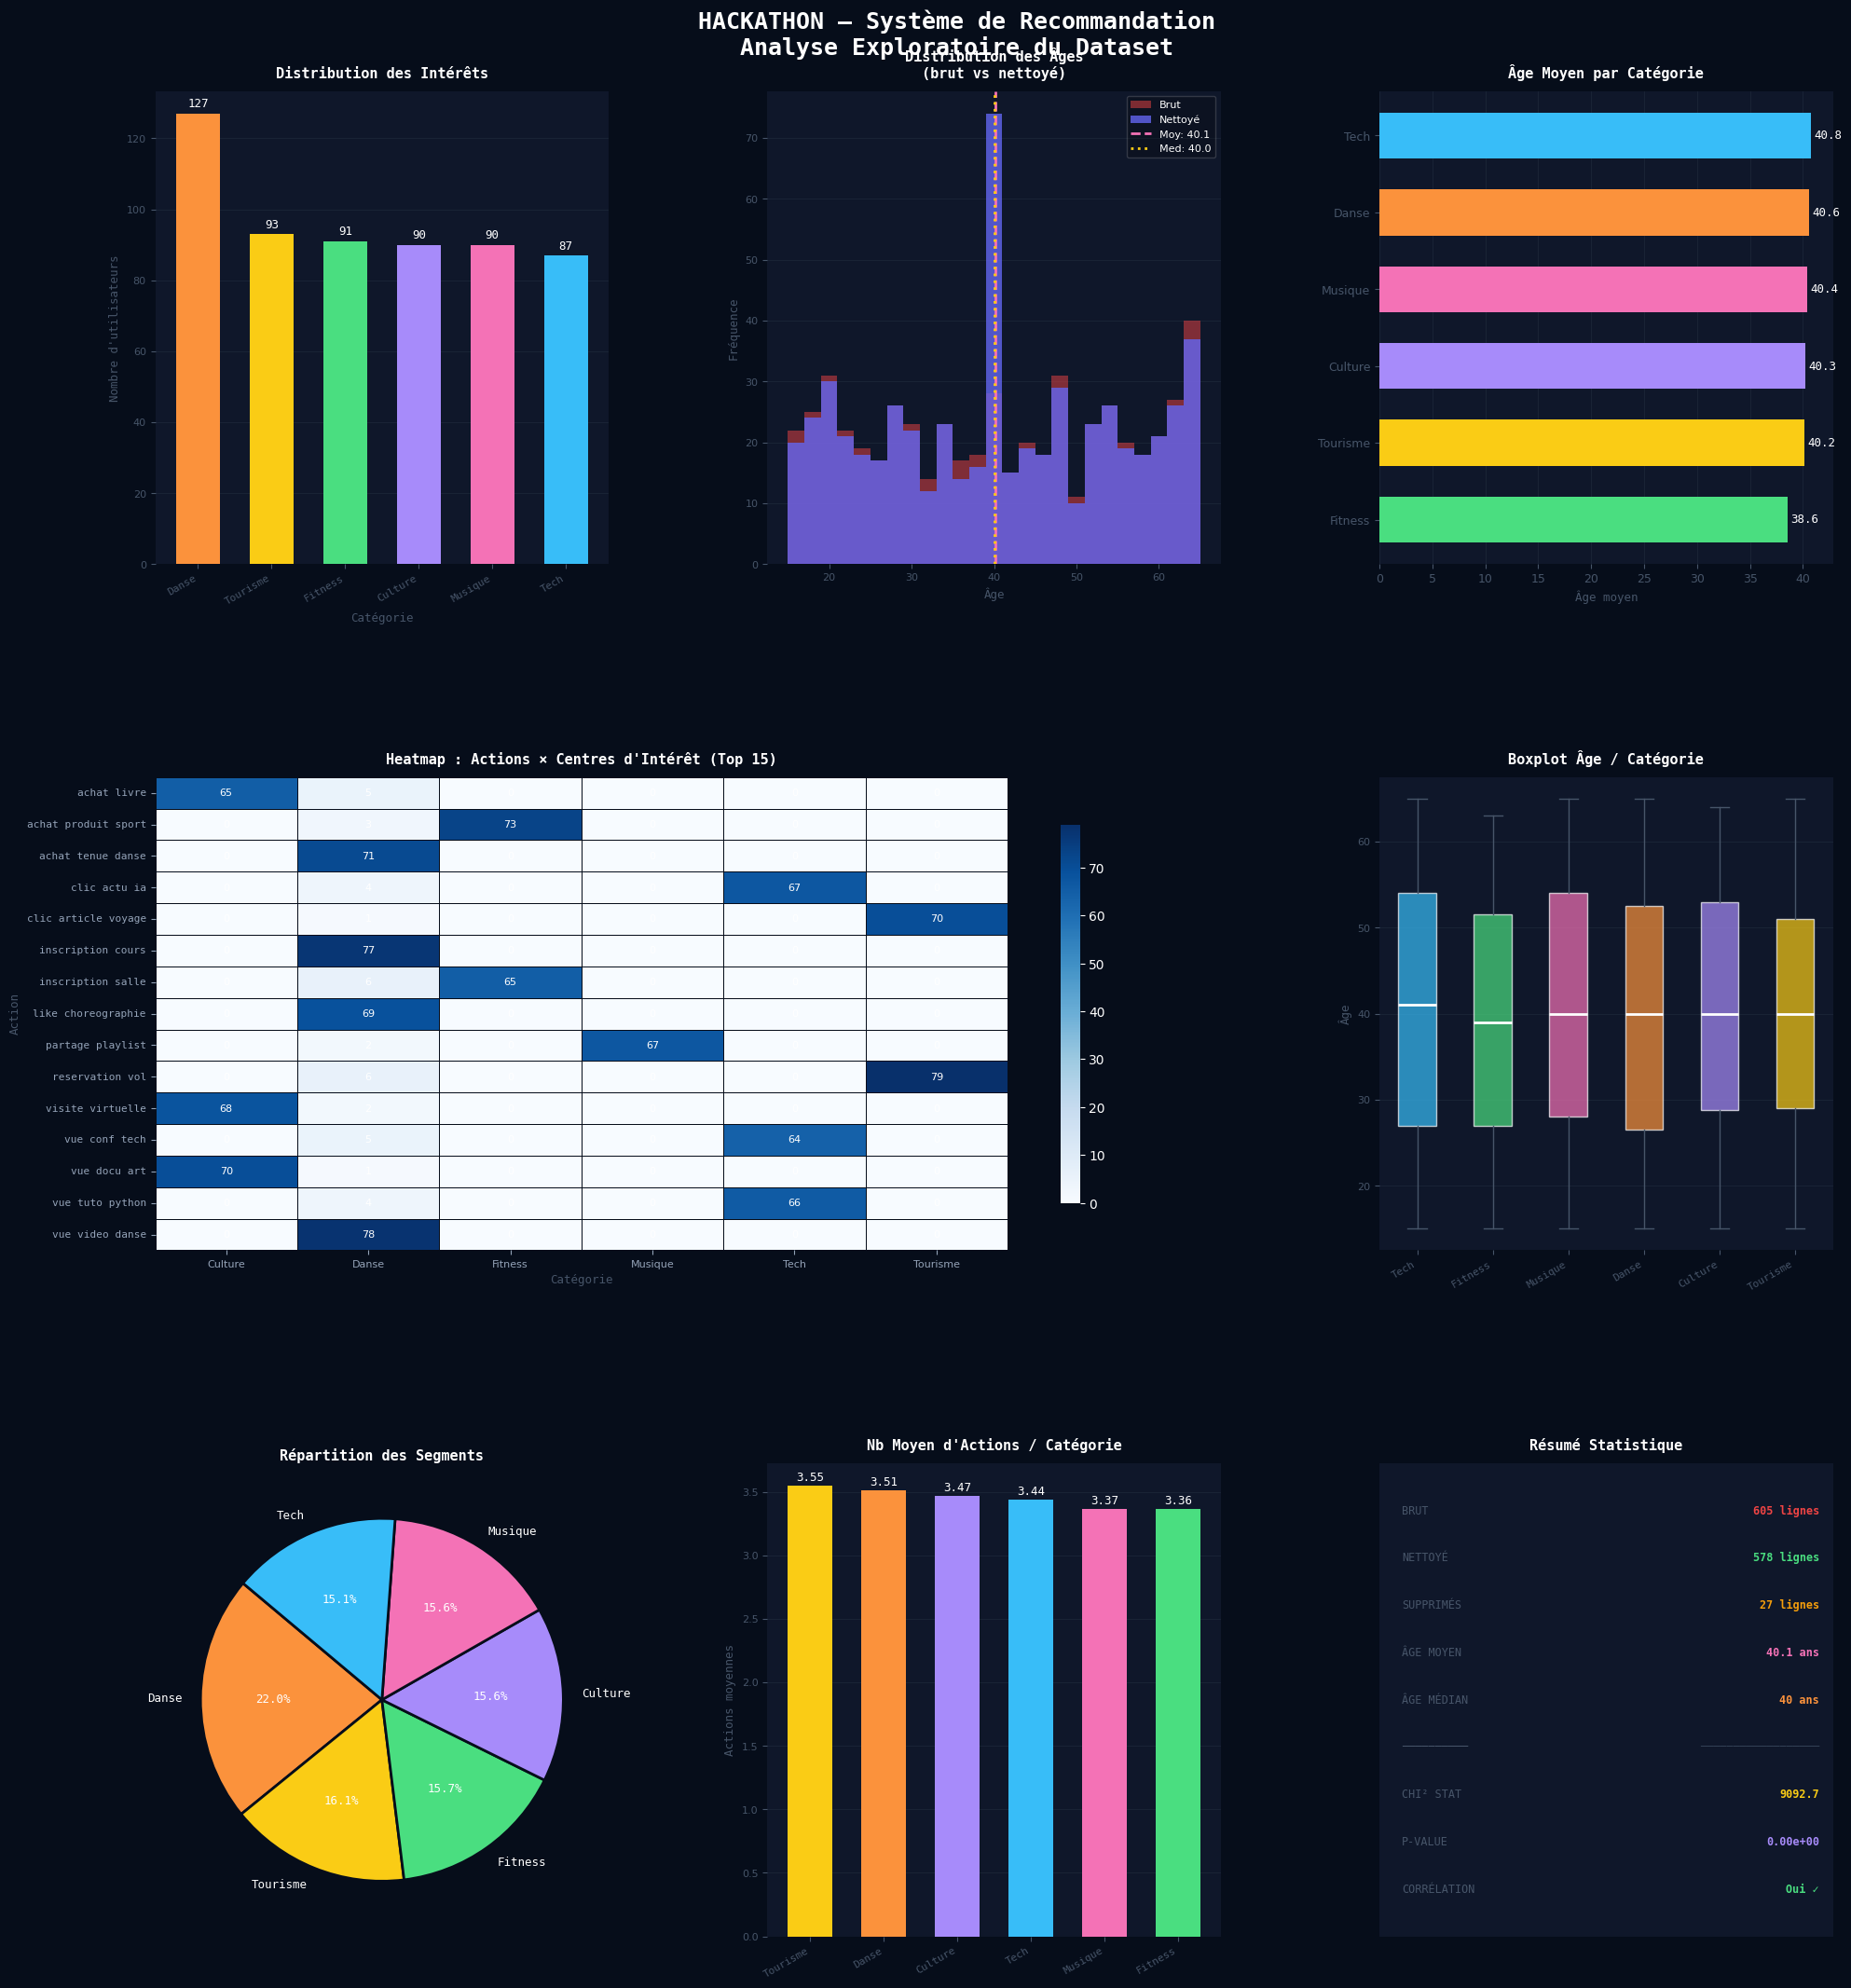

In [ ]:
#Visualisations
plt.style.use('dark_background')
COLORS = {
    'Tech':'#38bdf8', 'Fitness':'#4ade80', 'Musique':'#f472b6',
    'Danse':'#fb923c', 'Culture':'#a78bfa', 'Tourisme':'#facc15'
}

fig = plt.figure(figsize=(20, 22), facecolor='#060d1a')
fig.suptitle('HACKATHON — Système de Recommandation\nAnalyse Exploratoire du Dataset',
             fontsize=18, fontweight='bold', color='white', y=0.98, fontfamily='monospace')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35,
                       top=0.94, bottom=0.04, left=0.07, right=0.97)

# 1. Distribution intérêts
ax1 = fig.add_subplot(gs[0, 0])
cat_counts = df_clean['Centre_interet'].value_counts()
bars1 = ax1.bar(cat_counts.index, cat_counts.values,
                color=[COLORS[c] for c in cat_counts.index], edgecolor='none', width=0.6)
for bar, val in zip(bars1, cat_counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(val), ha='center', va='bottom', fontsize=9, color='white', fontfamily='monospace')
ax1.set_facecolor('#0f172a')
ax1.set_title('Distribution des Intérêts', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax1.set_xlabel('Catégorie', color='#475569', fontsize=9, fontfamily='monospace')
ax1.set_ylabel("Nombre d'utilisateurs", color='#475569', fontsize=9, fontfamily='monospace')
ax1.tick_params(colors='#475569', labelsize=8)
ax1.set_xticklabels(cat_counts.index, rotation=30, ha='right', fontfamily='monospace')
for s in ax1.spines.values(): s.set_visible(False)
ax1.yaxis.grid(True, color='#1e293b', linewidth=0.5); ax1.set_axisbelow(True)

# 2. Âges brut vs nettoyé
ax2 = fig.add_subplot(gs[0, 1])
ages_brut   = df['AGE'].dropna()
ages_brut   = ages_brut[(ages_brut >= 0) & (ages_brut <= 120)]
ages_propre = df_clean['AGE']
ax2.hist(ages_brut,   bins=25, color='#ef4444', alpha=0.5, label='Brut',    edgecolor='none')
ax2.hist(ages_propre, bins=25, color='#6366f1', alpha=0.8, label='Nettoyé', edgecolor='none')
ax2.axvline(ages_propre.mean(),   color='#f472b6', linewidth=2, linestyle='--', label=f"Moy: {ages_propre.mean():.1f}")
ax2.axvline(ages_propre.median(), color='#facc15', linewidth=2, linestyle=':', label=f"Med: {ages_propre.median():.1f}")
ax2.set_facecolor('#0f172a')
ax2.set_title('Distribution des Âges\n(brut vs nettoyé)', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax2.set_xlabel('Âge', color='#475569', fontsize=9, fontfamily='monospace')
ax2.set_ylabel('Fréquence', color='#475569', fontsize=9, fontfamily='monospace')
ax2.tick_params(colors='#475569', labelsize=8)
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white')
for s in ax2.spines.values(): s.set_visible(False)
ax2.yaxis.grid(True, color='#1e293b', linewidth=0.5); ax2.set_axisbelow(True)

# 3. Âge moyen par catégorie
ax3 = fig.add_subplot(gs[0, 2])
age_by_cat = df_clean.groupby('Centre_interet')['AGE'].mean().sort_values()
bars3 = ax3.barh(age_by_cat.index, age_by_cat.values,
                 color=[COLORS[c] for c in age_by_cat.index], edgecolor='none', height=0.6)
for bar, val in zip(bars3, age_by_cat.values):
    ax3.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9, color='white', fontfamily='monospace')
ax3.set_facecolor('#0f172a')
ax3.set_title('Âge Moyen par Catégorie', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax3.set_xlabel('Âge moyen', color='#475569', fontsize=9, fontfamily='monospace')
ax3.tick_params(colors='#475569', labelsize=9)
for s in ax3.spines.values(): s.set_visible(False)
ax3.xaxis.grid(True, color='#1e293b', linewidth=0.5); ax3.set_axisbelow(True)

# 4. Heatmap
ax4 = fig.add_subplot(gs[1, :2])
pivot = contingence.T
top_actions = df_exp['action'].value_counts().head(15).index
pivot_top = pivot.loc[pivot.index.intersection(top_actions)].copy()
pivot_top.index = [i.replace('_', ' ') for i in pivot_top.index]
sns.heatmap(pivot_top, ax=ax4, cmap='Blues', linewidths=0.5, linecolor='#060d1a',
            annot=True, fmt='d', annot_kws={'size': 8, 'color': 'white'}, cbar_kws={'shrink': 0.8})
ax4.set_facecolor('#0f172a')
ax4.set_title("Heatmap : Actions × Centres d'Intérêt (Top 15)", color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax4.set_xlabel('Catégorie', color='#475569', fontsize=9, fontfamily='monospace')
ax4.set_ylabel('Action', color='#475569', fontsize=9, fontfamily='monospace')
ax4.tick_params(colors='#94a3b8', labelsize=8)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontfamily='monospace')

# 5. Boxplot
ax5 = fig.add_subplot(gs[1, 2])
data_box = [df_clean[df_clean['Centre_interet']==c]['AGE'].values for c in categories]
bp = ax5.boxplot(data_box, patch_artist=True,
                 medianprops={'color':'white','linewidth':2},
                 whiskerprops={'color':'#475569'}, capprops={'color':'#475569'},
                 flierprops={'marker':'o','markerfacecolor':'#ef4444','markersize':3,'alpha':0.5})
for patch, cat in zip(bp['boxes'], categories):
    patch.set_facecolor(COLORS[cat]); patch.set_alpha(0.7)
ax5.set_facecolor('#0f172a')
ax5.set_title('Boxplot Âge / Catégorie', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax5.set_xticklabels(categories, rotation=30, ha='right', fontsize=8, color='#94a3b8', fontfamily='monospace')
ax5.tick_params(colors='#475569', labelsize=8)
ax5.set_ylabel('Âge', color='#475569', fontsize=9, fontfamily='monospace')
for s in ax5.spines.values(): s.set_visible(False)
ax5.yaxis.grid(True, color='#1e293b', linewidth=0.5); ax5.set_axisbelow(True)

# 6. Camembert
ax6 = fig.add_subplot(gs[2, 0])
rec_counts = df_clean['Centre_interet'].value_counts()
ax6.pie(rec_counts.values, labels=rec_counts.index,
        colors=[COLORS[c] for c in rec_counts.index],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor':'#060d1a','linewidth':2},
        textprops={'color':'white','fontsize':9,'fontfamily':'monospace'})
ax6.set_facecolor('#0f172a')
ax6.set_title('Répartition des Segments', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)

# 7. Nb moyen d'actions
ax7 = fig.add_subplot(gs[2, 1])
df_clean['nb_actions'] = df_clean['activity_log'].apply(len)
avg_actions = df_clean.groupby('Centre_interet')['nb_actions'].mean().sort_values(ascending=False)
bars7 = ax7.bar(avg_actions.index, avg_actions.values,
                color=[COLORS[c] for c in avg_actions.index], edgecolor='none', width=0.6)
for bar, val in zip(bars7, avg_actions.values):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, color='white', fontfamily='monospace')
ax7.set_facecolor('#0f172a')
ax7.set_title("Nb Moyen d'Actions / Catégorie", color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
ax7.set_ylabel('Actions moyennes', color='#475569', fontsize=9, fontfamily='monospace')
ax7.tick_params(colors='#475569', labelsize=8)
ax7.set_xticklabels(avg_actions.index, rotation=30, ha='right', fontfamily='monospace')
for s in ax7.spines.values(): s.set_visible(False)
ax7.yaxis.grid(True, color='#1e293b', linewidth=0.5); ax7.set_axisbelow(True)

# 8. Résumé statistique
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor('#0f172a'); ax8.set_xlim(0,1); ax8.set_ylim(0,1)
for s in ax8.spines.values(): s.set_visible(False)
ax8.set_xticks([]); ax8.set_yticks([])
ax8.set_title('Résumé Statistique', color='white', fontsize=11, fontweight='bold', fontfamily='monospace', pad=10)
stats_lines = [
    ("BRUT",        f"{len(df)} lignes",                   '#ef4444'),
    ("NETTOYÉ",     f"{len(df_clean)} lignes",             '#4ade80'),
    ("SUPPRIMÉS",   f"{len(df)-len(df_clean)} lignes",     '#f59e0b'),
    ("ÂGE MOYEN",   f"{df_clean['AGE'].mean():.1f} ans",   '#f472b6'),
    ("ÂGE MÉDIAN",  f"{df_clean['AGE'].median():.0f} ans", '#fb923c'),
    ("──────────",  "──────────────────",                  '#334155'),
    ("CHI² STAT",   f"{chi2_stat:.1f}",                    '#facc15'),
    ("P-VALUE",     f"{p_value:.2e}",                      '#a78bfa'),
    ("CORRÉLATION", "Oui ✓" if p_value<0.05 else "Non ✗",
                    '#4ade80' if p_value<0.05 else '#ef4444'),
]
for i, (label, val, color) in enumerate(stats_lines):
    y = 0.90 - i*0.10
    ax8.text(0.05, y, label, color='#475569', fontsize=8.5, fontfamily='monospace',
             transform=ax8.transAxes, va='center')
    ax8.text(0.97, y, val, color=color, fontsize=8.5, fontfamily='monospace',
             transform=ax8.transAxes, va='center', ha='right', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()